In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skimage
import tifffile

In [2]:
image = tifffile.imread("/Users/fdrgsp/Desktop/t/frame_EColi_1_MMStack_Pos0_ph.tif")
labeled_mask = tifffile.imread("/Users/fdrgsp/Desktop/t/EColi_2_MMStack_Pos0_labels.tif")

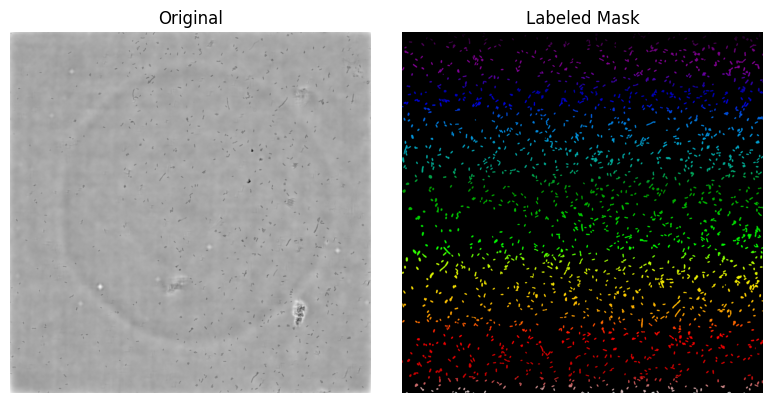

In [3]:
fig, axis = plt.subplots(1, 2, figsize=(8, 4))
axis[0].imshow(image, cmap="gray")
axis[0].set_title("Original")
axis[0].axis("off")
axis[1].imshow(labeled_mask, cmap="nipy_spectral")
axis[1].set_title("Labeled Mask")
axis[1].axis("off")

plt.tight_layout()
plt.show()

In [4]:
props_dict = skimage.measure.regionprops_table(
    labeled_mask, intensity_image=image, properties=["label", "intensity_mean", "area", "eccentricity", "axis_major_length", "axis_minor_length"]
)
print(props_dict.keys())

dict_keys(['label', 'intensity_mean', 'area', 'eccentricity', 'axis_major_length', 'axis_minor_length'])


In [5]:
props_df = pd.DataFrame(props_dict)
print(props_df)

      label  intensity_mean  area  eccentricity  axis_major_length  \
0         1        0.549944  93.0      0.679603          12.848179   
1         2        0.164360  55.0      0.763897          11.435444   
2         3        0.182757  45.0      0.737386           9.343419   
3         4        0.197670  92.0      0.950832          19.679955   
4         5        0.207116  78.0      0.863765          14.015900   
...     ...             ...   ...           ...                ...   
2306   2307        0.414374  41.0      0.923078          11.729203   
2307   2308        0.231695  20.0      0.910393           7.731011   
2308   2309        0.127610  26.0      0.899789           8.734537   
2309   2310        0.123720  37.0      0.972108          14.965803   
2310   2311        0.279213  21.0      0.925138           8.352497   

      axis_minor_length  
0              9.425173  
1              7.379727  
2              6.311212  
3              6.095021  
4              7.062531  
...

<Axes: title={'center': 'Area Distribution'}, ylabel='Frequency'>

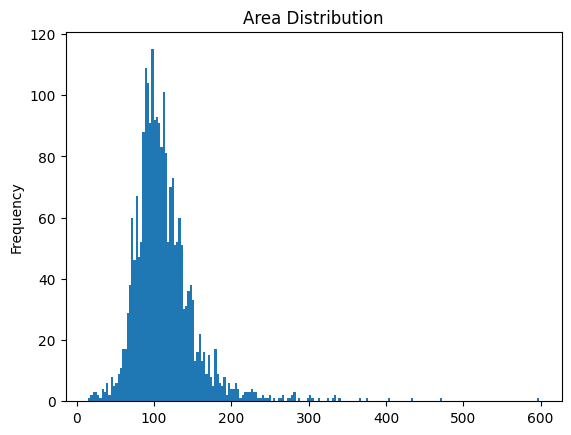

In [8]:
props_df["area"].plot(kind="hist", bins=200, title="Area Distribution")

<Axes: title={'center': 'Eccentricity Distribution'}, ylabel='Frequency'>

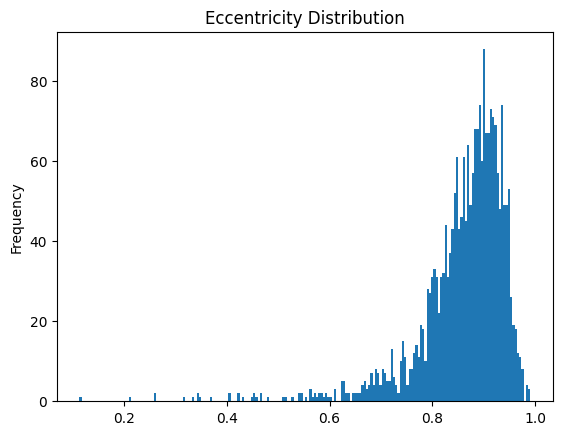

In [12]:
props_df["eccentricity"].plot(kind="hist", bins=200, title="Eccentricity Distribution")

<Axes: title={'center': 'Axis Major Length Distribution'}, ylabel='Frequency'>

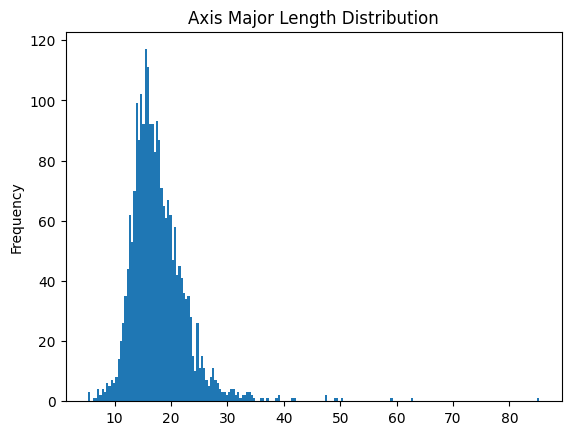

In [15]:
props_df["axis_major_length"].plot(kind="hist", bins=200, title="Axis Major Length Distribution")

<Axes: title={'center': 'Axis Minor Length Distribution'}, ylabel='Frequency'>

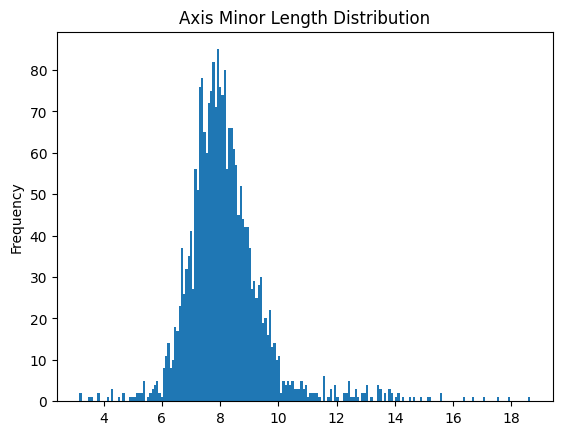

In [16]:
props_df["axis_minor_length"].plot(kind="hist", bins=200, title="Axis Minor Length Distribution")